A neural image recovery of the temperature structure of v4046 Sgr
---


In [83]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import os, sys
import matplotlib
from pathlib import Path
from ruamel.yaml import YAML
from tqdm.auto import tqdm
from gofish import imagecube
from mpl_toolkits.axes_grid1 import make_axes_locatable
import emcee, corner
from collections import OrderedDict
import tensorboardX
from flax.training import checkpoints

os.environ['CUDA_VISIBLE_DEVICES'] = '0,1,2,3,4'

sys.path.insert(0, '../')
import visualization, sensor, grid, line_rte, parametric_disk, inference, network
from network import shard
from consts import *

In [84]:
def render_cube(ray_coords, pixel_area, disk, nd_co, temperature, velocity_az, bbox, freqs, nu0):
    ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
    ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
    
    # Interpolate dataset along the ray coordinates
    gas_nd = grid.interpolate_scalar(nd_co, ray_coords_polar, bbox)
    gas_t  = grid.interpolate_scalar(temperature, ray_coords_polar, bbox, cval=1e-10)
    gas_v_az = grid.interpolate_scalar(velocity_az, ray_coords_polar, bbox)
    gas_v = parametric_disk.azimuthal_velocity(ray_coords, gas_v_az)
    
    # Einstein coefficient for spontaneous emission from level u to level d
    energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=disk.molecule_table)
    _, a_ud, b_ud, b_du = line_rte.einstein_coefficients(energy_levels, radiative_transitions, transition=disk.transition)
    n_up, n_dn = line_rte.n_up_down(gas_nd, gas_t, energy_levels, radiative_transitions, transition=disk.transition)

    alpha_tot = line_rte.alpha_total_co(disk.v_turb, gas_t)

    print('computing spectral cube for a total of {} frequencies'.format(freqs.size))
    images = line_rte.compute_spectral_cube_pmap(shard(freqs), gas_v, alpha_tot, n_up, n_dn, a_ud, b_ud, b_du, ray_coords, obs_dir, nu0, pixel_area)
    images = np.nan_to_num(images).reshape(freqs.size, *ray_coords.shape[:2])
    return images

def intensity_to_nchw(intensity, vmin=None, vmax=None, cmap='viridis', gamma=0.5):
    cm = plt.get_cmap(cmap)
    if vmin is None: vmin = np.min(intensity)
    if vmax is None: vmax = np.max(intensity)
    norm_images = np.flip(( (intensity - vmin) / (vmax - vmin) )**gamma, axis=-2)
    if intensity.ndim == 2:
        nchw_images = np.moveaxis(cm(norm_images)[...,:3], (0, 1, 2), (1, 2, 0))
    elif intensity.ndim == 3:
        nchw_images = np.moveaxis(cm(norm_images)[...,:3], (0, 1, 2, 3), (0, 2, 3, 1))
    return nchw_images

In [85]:
fov_as = 14.0   # arcsecs
velocity_range = (-1097.0, 6903.0) # m/s

data_path = '../data/alma/V4046_Sgr_12CO.contsub_beam0.15_100ms_3sigma.clean.image.fits'
data_dir = Path(data_path).parent

data_cube = imagecube(data_path, FOV=fov_as, velocity_range=velocity_range)

data = data_cube.data
velocities = data_cube.velax
freqs = data_cube.velocity_to_restframe_frequency()
num_freqs = len(freqs)
x_sky, y_sky = np.meshgrid(data_cube.xaxis, data_cube.yaxis, indexing='xy')

nu0 = data_cube.nu0
npix = data_cube.nxpix
width_kms = (velocities[-1] - velocities[0]) / 1000.0
delta_v_ms = velocities[1] - velocities[0]
print('velocity resolution: {} m/s'.format(delta_v_ms))
      
# Center the velocities around n0 by removing systemic component
freqs += nu0 - freqs.mean()

velocity resolution: 100.0000000275138 m/s


interactive(children=(IntSlider(value=39, description='frame', max=79), Output()), _dom_classes=('widget-inter…

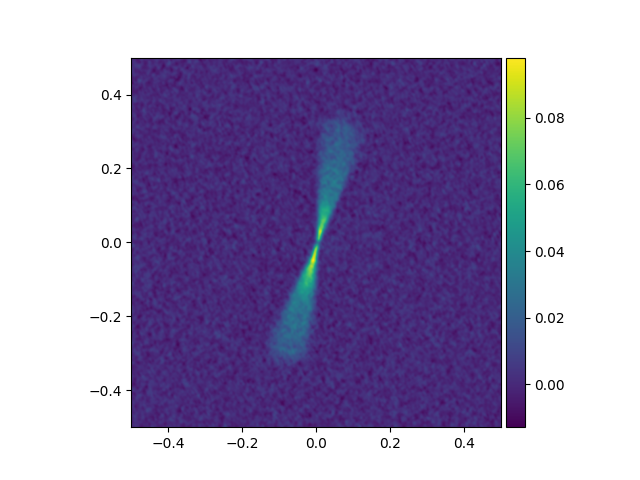

In [86]:
%matplotlib widget
visualization.slider(data)

# Fiducial model

In [88]:
disk = parametric_disk.DiskFlaherty(
    name='v4046_CO(3-2)',
    q=-0.565,
    q_in=0,
    r_break=-np.inf,
    log_r_c=1.939,
    v_turb=0.15,
    T_atm1=27.84,
    gamma=1.0,
    T_mid1=12.0,
    M_star=1.75*M_sun,
    r_in=7.0,
    M_gas=0.09*M_sun,
    co_abundance=3e-6,
    N_dissoc=1.3e21,
    N_desorp=4.8e21,
    freezeout=20.0,
    r_scale=150.0,
    z_q0=35.0,
    delta=1,
    transition=3,
    m_mol=2.37*m_h,
    molecule_table='../molecular_tables/molecule_12c16o.inp',
)

resolution = 500
z_min, z_max = 0, 200
r_min, r_max = disk.r_in, 800
z_disk, r_disk = jnp.meshgrid(jnp.linspace(z_min, z_max, resolution), jnp.linspace(r_min, r_max, resolution), indexing='ij')

temperature = disk.temperature_profile(z_disk, r_disk)
nd_h2 = parametric_disk.number_density_profile(z_disk, r_disk, temperature, disk.gamma, disk.r_in, 10**disk.log_r_c, disk.M_gas, disk.M_star, disk.m_mol)
velocity_az = disk.velocity(z_disk, r_disk, nd_h2, temperature)

# Compute the column integrated density N(h2) (units of 1/cm^2)
N_h2 = parametric_disk.surface_density(z_disk, nd_h2)
sigma_h2 = N_h2 * m_h

# Compute the relative abundance of co
abundance_co = disk.co_abundance_profile(N_h2, temperature)
nd_co = abundance_co * nd_h2

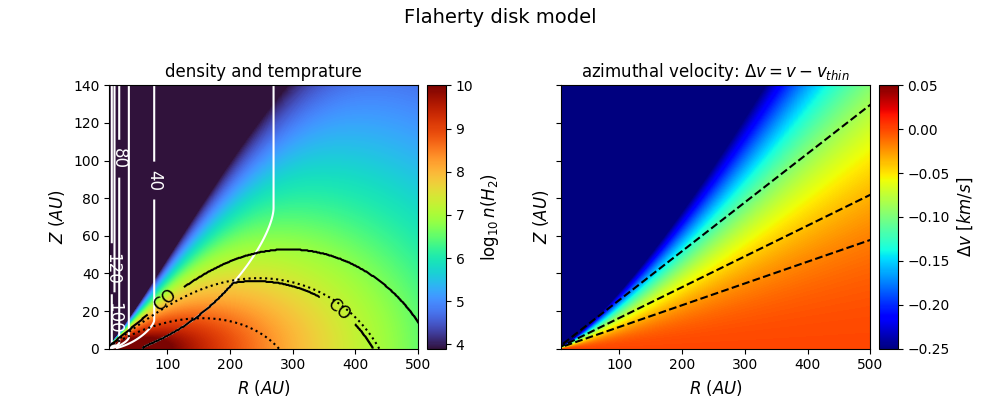

In [89]:
%matplotlib widget
fig, axes = plt.subplots(1,2, figsize=(10,4), sharey=True)
im = axes[0].imshow(np.log10(nd_h2), origin='lower', cmap='turbo', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], vmin=3.9, vmax=10, aspect=3);

divider = make_axes_locatable(axes[0])
cax = divider.append_axes('right', size='2%', pad=-3.)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)

levels = [20, 40, 60, 80, 100, 120]
cp = axes[0].contour(r_disk, z_disk, temperature, levels, colors='white')
axes[0].clabel(cp, levels, inline=1, fontsize=12);
cp = axes[0].contour(r_disk, z_disk, abundance_co, levels=[disk.co_abundance/2], colors='black')
axes[0].clabel(cp, levels=[disk.co_abundance/2], fmt='CO', inline=1, fontsize=12);
cp = axes[0].contour(r_disk, z_disk, sigma_h2, levels=[0.01, 0.1], colors='black', linestyles='dotted')


# Plot azimuthal velocity 
v_thin = np.sqrt(parametric_disk.vsq_keplerian_thin_disk(r_disk, disk.M_star))
delta_v = (velocity_az-v_thin)
im = axes[1].imshow(1e-5*delta_v, cmap='jet', vmin=-0.25, vmax=0.05, origin='lower', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], aspect=3)
divider = make_axes_locatable(axes[1])
cax = divider.append_axes('right', size='2%', pad=-3.)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\Delta v~[km/s]$', fontsize=12)
cp = axes[1].contour(r_disk, z_disk, 100*delta_v/velocity_az, levels=[-5, -2, -1], colors='black')
plt.clabel(cp, [-5, -2, -1], inline=True, fontsize=12, fmt=lambda x:'{:.0f} %'.format(x));

for ax in axes:
    ax.set_xlabel(r'$R~(AU)$', fontsize=12)
    ax.set_ylabel(r'$Z~(AU)$', fontsize=12)
    ax.set_xlim(r_disk.min(),500)
    ax.set_ylim(0,140)

axes[0].set_title('density and temprature')
axes[1].set_title(r'azimuthal velocity: $\Delta v = v-v_{thin}$')
plt.suptitle('Flaherty disk model', fontsize=14, y=0.98);
plt.tight_layout()
fig.subplots_adjust(left=-0.2, wspace=-0.3)

In [90]:
projection = sensor.PinholeProjection(
    name=disk.name,
    x_sky=x_sky,
    y_sky=y_sky,
    distance=72.26, 
    nray=100,
    incl=34.69,
    phi=0.0,
    posang=75.7,
    z_width=2*z_max,
    freqs=freqs
)
# Bounding box for interpolations
bbox_disk = jnp.array([(au*z_min, au*z_max), (au*r_min, au*r_max)])
beam = data_cube.beams_per_pix * sensor.beam(data_cube.dpix, data_cube.bmaj, data_cube.bmin, data_cube.bpa)

fov_rad =  fov_as*arcsec                  # field of view 
fov = 2 * projection.distance*pc * np.tan(fov_rad/2.0)  # gives ~1708 [au]
pixel_area = (fov/npix)**2
ray_coords, obs_dir = sensor.pinhole_disk_projection(
    projection.x_sky, projection.y_sky, projection.distance, projection.nray, 
    projection.incl, projection.phi, projection.posang, projection.z_width
)

# Render spectral cube and convolve with gaussian beam
images = render_cube(ray_coords, pixel_area, disk, nd_co, temperature, velocity_az, bbox_disk, freqs, nu0)
images_blurred = sensor.fftconvolve_vmap(images, beam)

computing spectral cube for a total of 80 frequencies


interactive(children=(IntSlider(value=39, description='frame', max=79), Output()), _dom_classes=('widget-inter…

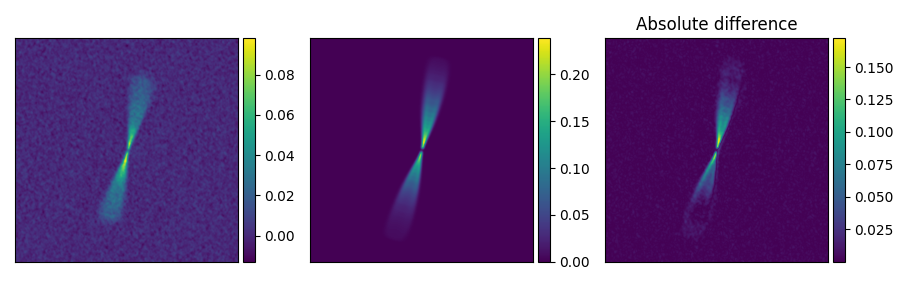

In [78]:
%matplotlib widget
visualization.slider_frame_comparison(data, images_blurred)

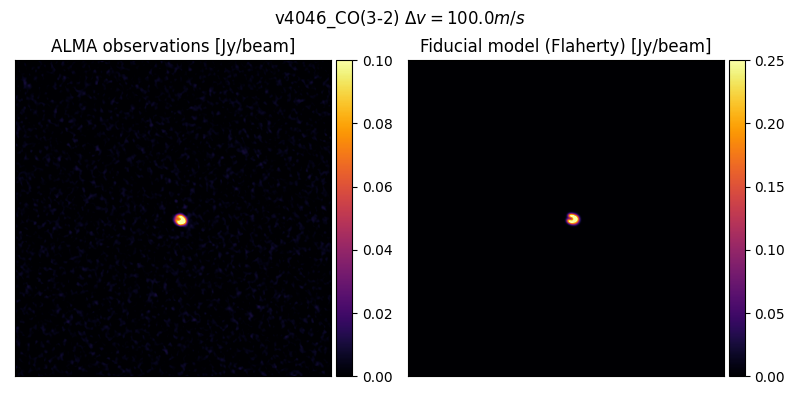

In [93]:
# Save a gif/plot for the data cube for quick visualization
%matplotlib widget
fig, axes = plt.subplots(1,2,figsize=(8,4))
fig.suptitle(r'{} $\Delta v = {:2.1f} m/s$'.format(disk.name, delta_v_ms))
titles = [r'ALMA observations [Jy/beam]', r'Fiducial model (Flaherty) [Jy/beam]']
visualization.animate_movies_synced([data, np.array(images_blurred)], axes, vmin=[0,0], vmax=[0.1, 0.25], 
                                    titles=titles, cmaps='inferno', fps=5, 
                                    output=data_path.replace('fits', 'Flaherty.gif'))

# Parameter inference using `emcee`

In [10]:
from jax import jit
from functools import partial
import flax
from datetime import datetime

@jax.tree_util.register_pytree_node_class
class NeuralTemperatureDisk(object):
    def __init__(self, z_disk, r_disk, bbox, pixel_area, ray_coords, ray_coords_polar, obs_dir, beam, 
                 energy_levels, radiative_transitions, disk):
        self.z_disk = z_disk
        self.r_disk = r_disk
        self.coords = jnp.stack((z_disk, r_disk), axis=-1).reshape(-1,2)
        self.bbox = bbox
        self.pixel_area = pixel_area
        self.ray_coords = ray_coords
        self.ray_coords_polar = ray_coords_polar
        self.obs_dir = obs_dir
        self.beam = beam
        self.energy_levels = energy_levels
        self.radiative_transitions = radiative_transitions
        self.disk = disk
        self.nu0, self.a_ud, self.b_ud, self.b_du = line_rte.einstein_coefficients(energy_levels, radiative_transitions, transition=disk.transition)
        self.disk_shape = z_disk.shape

    @partial(jit, static_argnums=(0, 2))
    def image_prediction(self, params, temp_fn, freqs):
            disk = self.disk
            temperature = temp_fn({'params': params}, self.coords).reshape(self.disk_shape)
        
            nd_h2 = parametric_disk.number_density_profile(
                self.z_disk, self.r_disk, temperature, disk.gamma, disk.r_in, 10**disk.log_r_c, disk.M_gas, disk.M_star, disk.m_mol
            )
            velocity_az = -disk.velocity(self.z_disk, self.r_disk, nd_h2, temperature)
            
            # Compute the column integrated density N(h2) (units of 1/cm^2)
            N_h2 = parametric_disk.surface_density(self.z_disk, nd_h2)
            
            # Compute the relative abundance of co
            abundance_co = disk.co_abundance_profile(N_h2, temperature)
            nd_co = abundance_co * nd_h2
            
            # Interpolate dataset along the ray coordinates
            gas_nd = grid.interpolate_scalar(nd_co, self.ray_coords_polar, self.bbox)
            gas_t  = grid.interpolate_scalar(temperature, self.ray_coords_polar, self.bbox, cval=1e-10)
            gas_v_az = grid.interpolate_scalar(velocity_az, self.ray_coords_polar, self.bbox)
            gas_v = parametric_disk.azimuthal_velocity(self.ray_coords, gas_v_az)
            
            # Einstein coefficient for spontaneous emission from level u to level d
            n_up, n_dn = line_rte.n_up_down(gas_nd, gas_t, self.energy_levels, self.radiative_transitions, transition=disk.transition)
            alpha_tot = line_rte.alpha_total_co(disk.v_turb, gas_t)
        
            model = jnp.nan_to_num(line_rte.compute_spectral_cube(
                freqs, gas_v, alpha_tot, n_up, n_dn, self.a_ud, self.b_ud, self.b_du, self.ray_coords, self.obs_dir, self.nu0, self.pixel_area
            ))
            model = sensor.fftconvolve_vmap(model, self.beam)
            return model
    
    def tree_flatten(self):
        children = (self.z_disk, self.r_disk, self.bbox, self.pixel_area, self.ray_coords, 
                    self.ray_coords_polar, self.obs_dir, self.beam, self.energy_levels, 
                    self.radiative_transitions, self.sigma, self.disk)
        aux_data = {}
        return (children, aux_data)

    @classmethod
    def tree_unflatten(cls, aux_data, children):
        return cls(*children, **aux_data) 


@partial(jit, static_argnums=(4,5))
def loss_fn(params, data, freqs, sigma, image_fn, temp_fn):
    model = image_fn(params, temp_fn, freqs)
    loss = jnp.mean(( (data-model)/sigma )**2)
    return loss
    
@partial(jit, static_argnums=(0, 1))
def gradient_step(loss_fn, image_fn, state, data, freqs, sigma):
    loss, grads = jax.value_and_grad(loss_fn, argnums=(0))(state.params, data, freqs, sigma, image_fn, state.apply_fn)
    grads = jax.lax.pmean(grads, axis_name='batch')
    loss = jax.lax.pmean(loss, axis_name='batch')
    state = state.apply_gradients(grads=grads)
    return loss, state

hparams = dict(
    run_name = 'SGD_with_full_cube',
    datetime = datetime.now().strftime('%Y-%m-%d.%H:%M:%S'),
    disk_name = disk.name,
    num_iters = 30000,
    posenc_deg = 4,
    sigma = 0.05,        # 5 mJy is ~1% noise level (peak of 0.5Jy)
    seed = 42,
    max_temp = 400.0,
    min_temp = 5.0,
    offset = 0.0,
    batchsize = 10 * jax.device_count(),
    z_max = z_max, 
    r_max = r_max
)


ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=disk.molecule_table)
energy_levels, radiative_transitions = jnp.array(energy_levels), jnp.array(radiative_transitions)
 
neural_temp = NeuralTemperatureDisk(
    z_disk, r_disk, bbox_disk, pixel_area, ray_coords, ray_coords_polar, obs_dir, 
    beam, energy_levels, radiative_transitions, disk, 
)

predictor = network.PixelPredictor(
    scale=np.array([hparams['z_max'], hparams['r_max']]), posenc_deg=hparams['posenc_deg'], 
    min_val=hparams['min_temp'], max_val=hparams['max_temp'], offset=hparams['offset']
)
params = predictor.init_params(neural_temp.coords, seed=hparams['seed'])
state = predictor.init_state(params, hparams['num_iters'])

# Replicate state and pmap for multiple gpus
state = flax.jax_utils.replicate(state)
grad_pmap = jax.pmap(gradient_step, axis_name='batch', in_axes=(None, None, 0, 0, 0, None), static_broadcasted_argnums=(0, 1))

In [11]:
log_cadance = 100
ckpt_cadance = 1000
num_test_images = 10

key = jax.random.key(hparams['seed'])
batch_indices = jax.random.randint(key, (hparams['num_iters'], hparams['batchsize']), minval=0, maxval=num_freqs)
test_indices = np.arange(0, num_freqs, num_freqs // num_test_images)[:num_test_images]

# Initialize logging and checkpoint directories
logdir = data_dir.joinpath('recovery/neural_temperature/{}/{}.{}'.format(hparams['disk_name'], hparams['run_name'], hparams['datetime']))
checkpoint_dir = logdir.absolute()
writer = tensorboardX.SummaryWriter(logdir=logdir)

yaml = YAML(typ='safe')
yaml.default_flow_style = False
with open(logdir.joinpath('hparams.yaml'), 'w') as file:
    yaml.dump(hparams, file)
    
# Add some intial logging of data, parametric residuals etc
i_min, i_max = data[test_indices].min(),  data[test_indices].max()
t_min, t_max = temperature.min(), temperature.max()
writer.add_image('temperature/parametric', intensity_to_nchw(temperature, t_min, t_max), global_step=0)
writer.add_images('fluxes/data', intensity_to_nchw(data[test_indices], i_min, i_max), global_step=0)
writer.add_images('fluxes/parametric', intensity_to_nchw(images_blurred[test_indices], i_min, i_max), global_step=0)
writer.add_images('fluxes/parametric_residual', intensity_to_nchw(np.abs(data[test_indices]-images_blurred[test_indices]), cmap='inferno'), global_step=0)

for step, batch in enumerate(tqdm(batch_indices)):
    
    if (step % log_cadance) == 0:
        current_state = jax.device_get(flax.jax_utils.unreplicate(state))
        current_params = current_state.params
        
        temperature_nn = np.array(predictor.apply({'params': current_params}, neural_temp.coords).reshape(neural_temp.disk_shape))
        test_images = np.array(neural_temp.image_prediction(current_params, predictor.apply, freqs[test_indices]))
        writer.add_image('temperature/neural', intensity_to_nchw(temperature_nn, t_min, t_max), global_step=step)
        writer.add_images('fluxes/neural', intensity_to_nchw(test_images, i_min, i_max), global_step=step)
        writer.add_images('fluxes/neural_residual', intensity_to_nchw(np.abs(data[test_indices]-test_images), cmap='inferno'), global_step=step)
        writer.add_scalar('test_datafit/neural', np.mean((data[test_indices]-test_images)**2), global_step=step)
        writer.add_scalar('test_datafit/parametric', np.mean((data[test_indices]-images_blurred[test_indices])**2), global_step=step)

                               
    if (step % ckpt_cadance) == 0:
        current_state = jax.device_get(flax.jax_utils.unreplicate(state))
        checkpoints.save_checkpoint(checkpoint_dir, current_state, step, keep=3)
        
    loss, state = grad_pmap(loss_fn, neural_temp.image_prediction, state, shard(data[batch]), shard(freqs[batch]), hparams['sigma'])
    writer.add_scalar('log_loss', np.log10(np.mean(loss)), global_step=step)

# Save final state
current_state = jax.device_get(flax.jax_utils.unreplicate(state))
checkpoints.save_checkpoint(checkpoint_dir, current_state, step+1, keep=3)

  0%|          | 0/30000 [00:00<?, ?it/s]

2024-06-28 15:46:06.905041: E external/xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %subtract.380 = f64[282,282,100,2]{3,2,1,0} subtract(f64[282,282,100,2]{3,2,1,0} %constant.128, f64[282,282,100,2]{3,2,1,0} %broadcast.379), metadata={op_name="jit(image_prediction)/jit(main)/sub" source_file="/scratch/imaging/projects/protoplanetary/radjax/notebooks/../grid.py" source_line=65}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2024-06-28 15:46:24.780996: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 18.876134333s
Constant folding an instruction is taking > 1s:

  %

'/scratch/imaging/projects/protoplanetary/radjax/data/alma/recovery/neural_temperature/HD163296_CO(2-1)/SGD_with_full_cube.2024-06-28.15:45:36/checkpoint_29999'

In [32]:
batch_indices = jax.random.randint(jax.random.split(key)[0], (hparams['num_iters'], 20000), minval=0, maxval=num_freqs)

In [ ]:
from tqdm.contrib import tzip

for step, batch in tzip(range(30000, 50000), batch_indices):
    
    if (step % log_cadance) == 0:
        current_state = jax.device_get(flax.jax_utils.unreplicate(state))
        current_params = current_state.params
        
        temperature_nn = np.array(predictor.apply({'params': current_params}, neural_temp.coords).reshape(neural_temp.disk_shape))
        test_images = np.array(neural_temp.image_prediction(current_params, predictor.apply, freqs[test_indices]))
        writer.add_image('temperature/neural', intensity_to_nchw(temperature_nn, t_min, t_max), global_step=step)
        writer.add_images('fluxes/neural', intensity_to_nchw(test_images, i_min, i_max), global_step=step)
        writer.add_images('fluxes/neural_residual', intensity_to_nchw(np.abs(data[test_indices]-test_images), cmap='inferno'), global_step=step)
        writer.add_scalar('test_datafit/neural', np.mean((data[test_indices]-test_images)**2), global_step=step)
        writer.add_scalar('test_datafit/parametric', np.mean((data[test_indices]-images_blurred[test_indices])**2), global_step=step)

                               
    if ((step % ckpt_cadance) == 0) and (step > 30000):
        current_state = jax.device_get(flax.jax_utils.unreplicate(state))
        checkpoints.save_checkpoint(checkpoint_dir, current_state, step, keep=3)
        
    loss, state = grad_pmap(loss_fn, neural_temp.image_prediction, state, shard(data[batch]), shard(freqs[batch]), hparams['sigma'])
    writer.add_scalar('log_loss', np.log10(np.mean(loss)), global_step=step)

# Save final state
current_state = jax.device_get(flax.jax_utils.unreplicate(state))
checkpoints.save_checkpoint(checkpoint_dir, current_state, step+1, keep=3)

  0%|          | 0/20000 [00:00<?, ?it/s]

# Analyze checkpoint

In [7]:
checkpoint_dir = Path('../data/alma/recovery/neural_temperature/HD163296_CO(2-1)/SGD_with_full_cube.2024-06-28.15:45:36')

with open(checkpoint_dir.joinpath('hparams.yaml'), 'r') as stream:
    hparams = YAML(typ='safe').load(stream)

predictor = network.PixelPredictor(
    scale=np.array([hparams['z_max'], hparams['r_max']]), posenc_deg=hparams['posenc_deg'], 
    min_val=hparams['min_temp'], max_val=hparams['max_temp'], offset=hparams['offset']
)

coords = jnp.stack((z_disk, r_disk), axis=-1).reshape(-1,2)
checkpoint_params = checkpoints.restore_checkpoint(checkpoint_dir, None)['params']
temperature_nn = np.array(predictor.apply({'params': checkpoint_params}, coords).reshape(resolution, resolution))

nd_h2_nn = parametric_disk.number_density_profile(
    z_disk, r_disk, temperature_nn, disk.gamma, disk.r_in, 10**disk.log_r_c, disk.M_gas, disk.M_star, disk.m_mol
)
velocity_az_nn = disk.velocity(z_disk, r_disk, nd_h2_nn, temperature_nn)

# Compute the column integrated density N(h2) (units of 1/cm^2)
N_h2_nn = parametric_disk.surface_density(z_disk, nd_h2_nn)

# Compute the relative abundance of co
abundance_co_nn = disk.co_abundance_profile(N_h2_nn, temperature_nn)
nd_co_nn = abundance_co_nn * nd_h2_nn

sigma_h2_nn = N_h2_nn * m_h

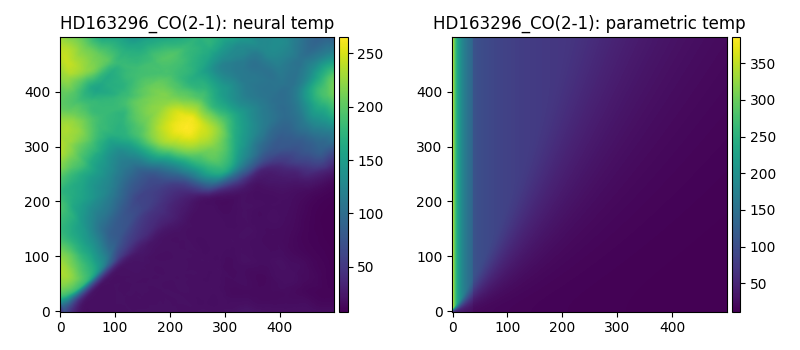

In [8]:
%matplotlib widget
fig, axes = plt.subplots(1, 2, figsize=(8,3.5))
titles = ['{}: neural temp', '{}: parametric temp']
images = [temperature_nn, temperature]
for ax, img, title in zip(axes, images, titles):
    im = ax.imshow(img, origin='lower')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='3%', pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    ax.set_title(title.format(disk.name))
plt.tight_layout()

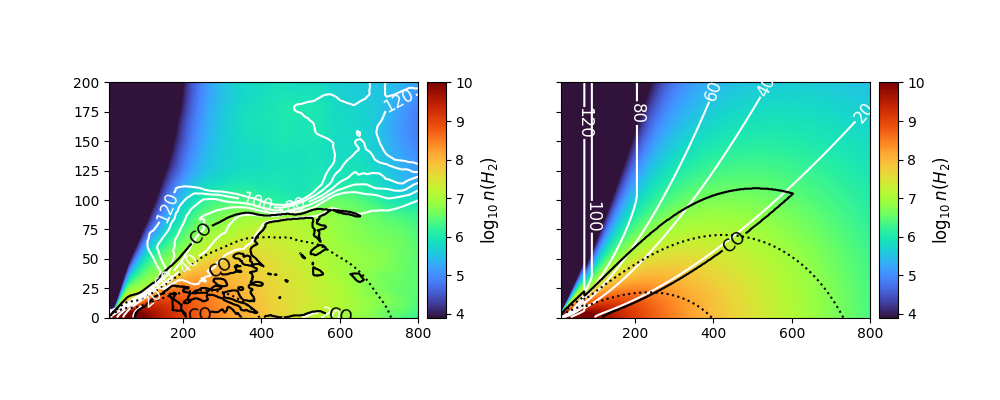

In [9]:
%matplotlib widget
fig, axes = plt.subplots(1,2, figsize=(10,4), sharey=True)
im = axes[0].imshow(np.log10(nd_h2_nn), origin='lower', cmap='turbo', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], vmin=3.9, vmax=10, aspect=3);
divider = make_axes_locatable(axes[0])
cax = divider.append_axes('right', size='2%', pad=-3)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)

levels = [20, 40, 60, 80, 100, 120]
cp = axes[0].contour(r_disk, z_disk, temperature_nn, levels, colors='white')
axes[0].clabel(cp, levels, inline=1, fontsize=12);
cp = axes[0].contour(r_disk, z_disk, abundance_co_nn, levels=[disk.co_abundance/2], colors='black')
axes[0].clabel(cp, levels=[disk.co_abundance/2], fmt='CO', inline=1, fontsize=12);
cp = axes[0].contour(r_disk, z_disk, sigma_h2_nn, levels=[0.01, 0.1], colors='black', linestyles='dotted')

im = axes[1].imshow(np.log10(nd_h2), origin='lower', cmap='turbo', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], vmin=3.9, vmax=10, aspect=3);
divider = make_axes_locatable(axes[1])
cax = divider.append_axes('right', size='2%', pad=-3)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)

cp = axes[1].contour(r_disk, z_disk, temperature, levels, colors='white')
axes[1].clabel(cp, levels, inline=1, fontsize=12);
cp = axes[1].contour(r_disk, z_disk, abundance_co, levels=[disk.co_abundance/2], colors='black')
axes[1].clabel(cp, levels=[disk.co_abundance/2], fmt='CO', inline=1, fontsize=12);
cp = axes[1].contour(r_disk, z_disk, sigma_h2, levels=[0.01, 0.1], colors='black', linestyles='dotted')

plt.tight_layout()
fig.subplots_adjust(left=-0.2, wspace=-0.3)

In [10]:
# Render spectral cube and convolve with gaussian beam
images = render_cube(ray_coords, pixel_area, disk, nd_co, temperature, -velocity_az, bbox_disk, freqs, nu0)
images_blurred = sensor.fftconvolve_vmap(images, beam)

images_nn = render_cube(ray_coords, pixel_area, disk, nd_co_nn, temperature_nn, -velocity_az_nn, bbox_disk, freqs, nu0)
images_blurred_nn = sensor.fftconvolve_vmap(images_nn, beam)

computing spectral cube for a total of 115 frequencies
computing spectral cube for a total of 115 frequencies


interactive(children=(IntSlider(value=57, description='frame', max=114), Output()), _dom_classes=('widget-inte…

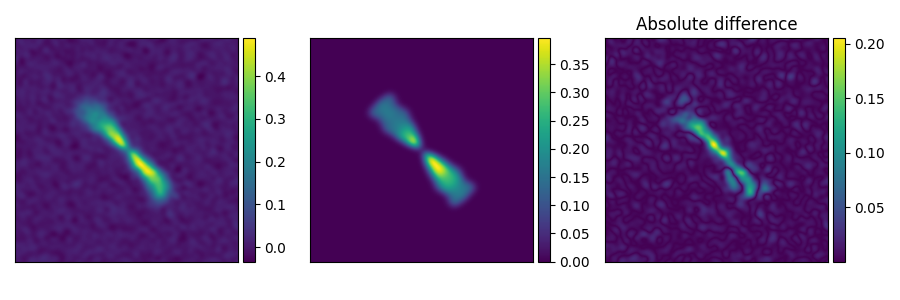

In [15]:
visualization.slider_frame_comparison(data, images_blurred_nn)

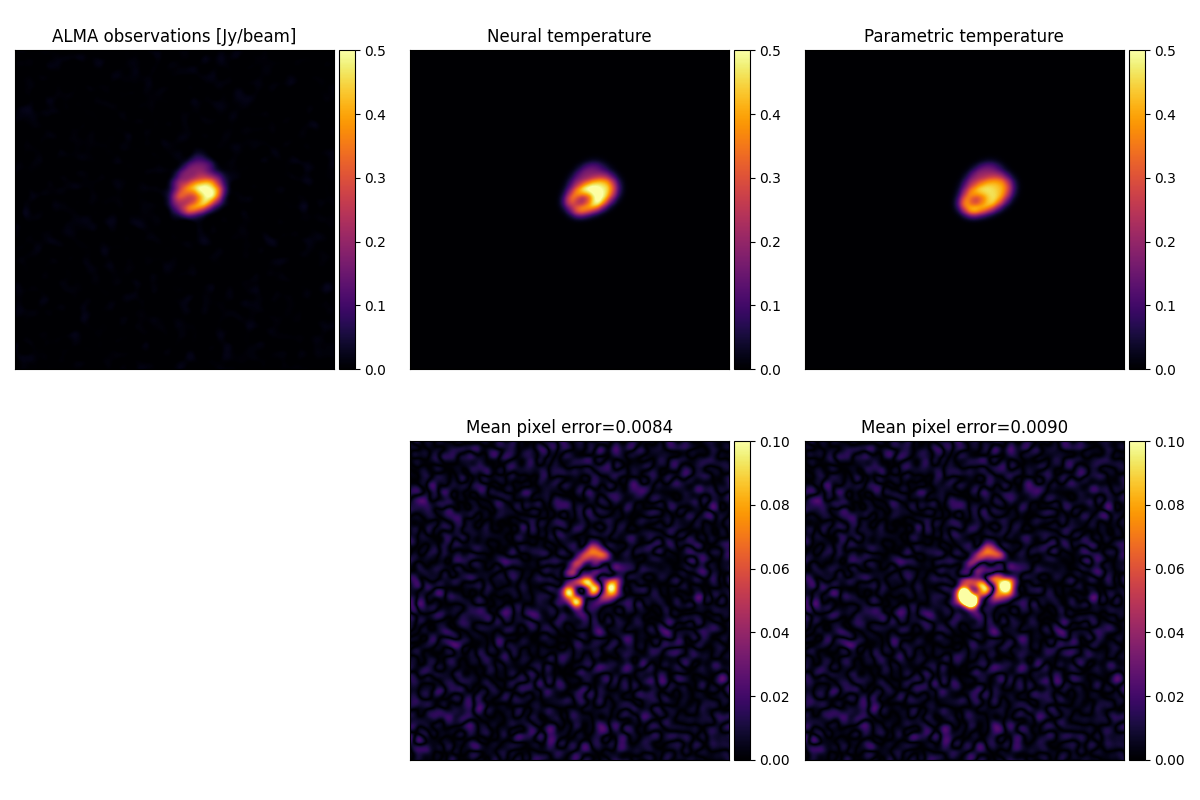

In [12]:
output = checkpoint_dir.joinpath('spectral_cubes_comparison_iter30000.gif')

# Save a gif/plot for the data cube for quick visualization
%matplotlib widget
fig, axes = plt.subplots(2,3,figsize=(12,8))
axes[1,0].axis("off")
axes_list = list(axes[0]) + list(axes[1,1:])

data_fit = np.abs(data - images_blurred).mean()
data_fit_nn = np.abs(data - images_blurred_nn).mean()
titles = [r'ALMA observations [Jy/beam]', 'Neural temperature', 'Parametric temperature',
          r'Mean pixel error={:1.4f}'.format(data_fit_nn), r'Mean pixel error={:1.4f}'.format(data_fit)]
movies = [data, np.array(images_blurred_nn), np.array(images_blurred),
         np.abs(data - images_blurred_nn), np.abs(data - images_blurred)]
visualization.animate_movies_synced(
    movies, axes_list, vmin=[0,0,0,0,0,0], vmax=[0.5,0.5,0.5,0.1,0.1], 
    titles=titles, cmaps='inferno', fps=3, writer='ffmpeg', output=output
)

In [ ]:
%matplotlib widget
fig, axes = plt.subplots(1,2, figsize=(10,3), sharey=True)

for ax, nd, temp, abund in zip(axes, [nd_h2, nd_h2_rj], [temperature, temperature_rj], [abundance_co, abundance_co_rj]):
    im = ax.imshow(np.log10(nd), origin='lower', cmap='turbo', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], vmin=3.9, vmax=10, aspect=3);
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='2%', pad=-2)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)

    levels = [20, 40, 60, 80, 100, 120]
    cp = ax.contour(r_disk, z_disk, temp, levels, colors='white')
    ax.clabel(cp, levels, inline=1, fontsize=12);
    cp = ax.contour(r_disk, z_disk, abund, levels=[5e-5], colors='black')
    ax.clabel(cp, levels=[5e-5], fmt='CO', inline=1, fontsize=12);

axes[0].set_title('Flaherty')
axes[1].set_title('Recovered')
plt.tight_layout()

In [ ]:
from IPython.display import display, Math
sigma = 5e-3

num_dof = len(posterior_params)
reduced_chi2_fl = np.mean(((images_blurred_fl - data)/sigma)**2) / num_dof
txt = "\chi^2_{{\mathrm{{Flaherty}}}} = {}"
txt = txt.format(reduced_chi2_fl)
display(Math(txt))

reduced_chi2_rj = np.mean(((images_blurred_rj - data)/sigma)**2) / num_dof
txt = "\chi^2_{{\mathrm{{radjax}}}} = {}"
txt = txt.format(reduced_chi2_rj)
display(Math(txt))